In [20]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn import model_selection, preprocessing, metrics
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import text, sequence

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalAveragePooling1D, Dense, Dropout

In [21]:
## LOAD DATA
train_data=pd.read_csv("/content/sample_data/train_subset.csv")
test_data=pd.read_csv("/content/sample_data/test.csv")

In [22]:
## TRAIN / TEST DATA Split
train = (train_data["Title"] + " " + train_data["Description"]).astype(str)
test = (test_data["Title"] + " " + test_data["Description"]).astype(str)

X = pd.concat([train, test], ignore_index=True)
y = pd.concat([train_data["Class Index"], test_data["Class Index"]], ignore_index=True)

train_x, test_x, train_y, test_y =  model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(train_x.shape, test_x.shape)

(15680,) (3920,)


In [23]:
encoder = preprocessing.LabelEncoder()
train_y = encoder.fit_transform(train_y)
test_y = encoder.fit_transform(test_y)
print(train_x[0:10])
print(train_y[0:10])

11908    Janco Partners Initiates Google with 'Sell' Ra...
13144    Symonds century lifts Australia LONDON, Englan...
4493     Korea #39;s chances for duplicate gold appear ...
7898     Longaberger reduces layoff plans to 784 The Lo...
6287     PCI: Charley not as devastating as Andrew The ...
1629     Rolling through rural China, train of doctors ...
1137     Bombs Explode in Nepal Capital as Rebel Siege ...
13936    Cameroon leader's 'divide and rule' Cameroonia...
4372     Profile: Chen Qi/Ma Lin, China #39;s new  amp;...
3623     Beckham:  #39;England needed this boost #39; D...
dtype: object
[3 1 1 2 2 0 0 0 1 1]


In [24]:
encoder = preprocessing.LabelEncoder()
train_y = encoder.fit_transform(train_y)
test_y = encoder.fit_transform(test_y)

token = text.Tokenizer()
token.fit_on_texts(X)
word_index = token.word_index
print(len(word_index)+1)

train_seq_x = sequence.pad_sequences(token.texts_to_sequences(train_x), maxlen=70)
test_seq_x = sequence.pad_sequences(token.texts_to_sequences(test_x), maxlen=70)
train_seq_x[0]


33238


array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0, 13222,  1593, 12695,   107,    12,
       27540,  3249,    15,    15, 13222,  1593,     7,    49, 10110,
        3219,     4,   107,    54,    12,     3,   541,  3249,     6,
           3,   195,   223,     4,   355,  3619,   728,   209,     1,
         617,    89,    56,   235,   226, 18679, 27541,    38,   297,
          18,  1379,   205, 11101,    17,   646,   121], dtype=int32)

In [25]:
vocab_size = len(word_index)+1
print("vocab_size:", vocab_size)
maxlen = 70

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=50))
model.build((None, maxlen))

model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

model.add(GlobalAveragePooling1D())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(train_seq_x,
                    train_y,
                    epochs=10,
                    batch_size=512,
                    validation_data=(test_seq_x, test_y),
                    verbose=1)
results = model.evaluate(test_seq_x, test_y)

print(results)

vocab_size: 33238


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 70, 50)         │     1,661,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 66, 128)        │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,696,109 (6.47 MB)

 Trainable params: 1,696,109 (6.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.2530 - loss: -0.2281 - val_accuracy: 0.2500 - val_loss: -9.2285
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2441 - loss: -20.7464 - val_accuracy: 0.2500 - val_loss: -95.5263
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2496 - loss: -166.4261 - val_accuracy: 0.2500 - val_loss: -515.3988
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2532 - loss: -754.2546 - val_accuracy: 0.2500 - val_loss: -1871.0557
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2550 - loss: -2435.1304 - val_accuracy: 0.2500 - val_loss: -5265.6416
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2519 - loss: -6728.8335 - val_accuracy: 0.2500 - val_loss: -12308.6816
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2520 - loss: -15127.7090 - val_accuracy: 0.2500 - val_loss: -25059.2617
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2478 -

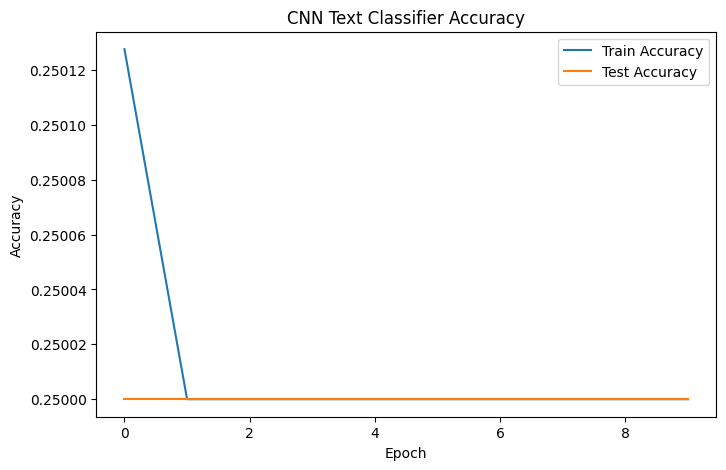

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Text Classifier Accuracy')
plt.legend()
plt.show()